# 02 - EDA y selección razonada de variables

El objetivo de este notebook no es entrenar modelos. Primero debemos entender la unidad de observación, el desbalance, la calidad de las variables y qué información estaría realmente disponible al hacer una predicción.

**Objetivo final:** dado un accidente ya ocurrido y una persona implicada, estimar la probabilidad de lesión grave o mortal. No podemos estimar la probabilidad de que ocurra un accidente porque la base no contiene situaciones sin accidente

In [20]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from tfm_accidentes.config import PROCESSED_DATA_DIR
from tfm_accidentes.data import build_quality_report, read_analysis_table

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

In [21]:
DATA_PATH = PROCESSED_DATA_DIR / 'accidentes_madrid_2019_2025.csv.gz'
if not DATA_PATH.exists():
    raise FileNotFoundError(
        'Primero ejecuta: python scripts/download_data.py'
    )

data = read_analysis_table(DATA_PATH)
print(f'Filas: {len(data):,}')
print(f'Expedientes: {data.num_expediente.nunique():,}')
print(f'Periodo: {data.fecha.min().date()} - {data.fecha.max().date()}')
data.head()

Filas: 322,317
Expedientes: 137,328
Periodo: 2019-01-01 - 2025-12-31


,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorologico,tipo_vehiculo,tipo_persona,rango_edad,sexo,cod_lesividad,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,anio_fichero,fecha_hora,anio,mes,dia_semana,es_fin_semana,hora_dia,es_noche,lesividad_conocida,lesion_grave
0,2018S017842,2019-02-04,9:10:00,"CALL. ALBERTO AGUILERA, 1",1,1,CENTRO,Colisión lateral,Despejado,Motocicleta > 125cc,Conductor,De 45 a 49 años,Hombre,07,Asistencia sanitaria sólo en el lugar del acci...,440068.0,4475679.0,N,NaN,2019,2019-02-04 09:10:00,2019,2,0,0,9,0,True,0
1,2018S017842,2019-02-04,9:10:00,"CALL. ALBERTO AGUILERA, 1",1,1,CENTRO,Colisión lateral,Despejado,Turismo,Conductor,De 30 a 34 años,Mujer,07,Asistencia sanitaria sólo en el lugar del acci...,440068.0,4475679.0,N,NaN,2019,2019-02-04 09:10:00,2019,2,0,0,9,0,True,0
2,2019S000001,2019-01-01,3:45:00,PASEO. SANTA MARIA DE LA CABEZA / PLAZA. ELIPTICA,168,11,CARABANCHEL,Alcance,NaN,Furgoneta,Conductor,De 40 a 44 años,Hombre,14,NaN,439139.0,4470836.0,S,NaN,2019,2019-01-01 03:45:00,2019,1,1,0,3,1,True,0
3,2019S000001,2019-01-01,3:45:00,PASEO. SANTA MARIA DE LA CABEZA / PLAZA. ELIPTICA,168,11,CARABANCHEL,Alcance,NaN,Turismo,Conductor,De 40 a 44 años,Mujer,14,NaN,439139.0,4470836.0,N,NaN,2019,2019-01-01 03:45:00,2019,1,1,0,3,1,True,0
4,2019S000001,2019-01-01,3:45:00,PASEO. SANTA MARIA DE LA CABEZA / PLAZA. ELIPTICA,168,11,CARABANCHEL,Alcance,NaN,Turismo,Conductor,De 45 a 49 años,Mujer,14,NaN,439139.0,4470836.0,N,NaN,2019,2019-01-01 03:45:00,2019,1,1,0,3,1,True,0


## 1. Muestra analítica y desbalance

Los códigos de lesividad desconocida se conservan en los datos preparados, pero no pueden utilizarse para entrenar o evaluar. La exclusión se realiza de forma explícita.

In [22]:
analysis = data.loc[data['lesion_grave'].notna()].copy()
analysis['lesion_grave'] = analysis['lesion_grave'].astype('int8')

target_counts = analysis['lesion_grave'].value_counts().sort_index()
target_prevalence = analysis['lesion_grave'].mean()

print(f'Registros excluidos por objetivo desconocido: {len(data) - len(analysis):,}')
print(f'Casos graves o mortales: {target_counts.get(1, 0):,}')
print(f'Prevalencia: {target_prevalence:.2%}')
print(f'Accuracy del clasificador trivial siempre-no-grave: {1-target_prevalence:.2%}')

Registros excluidos por objetivo desconocido: 13
Casos graves o mortales: 3,796
Prevalencia: 1.18%
Accuracy del clasificador trivial siempre-no-grave: 98.82%


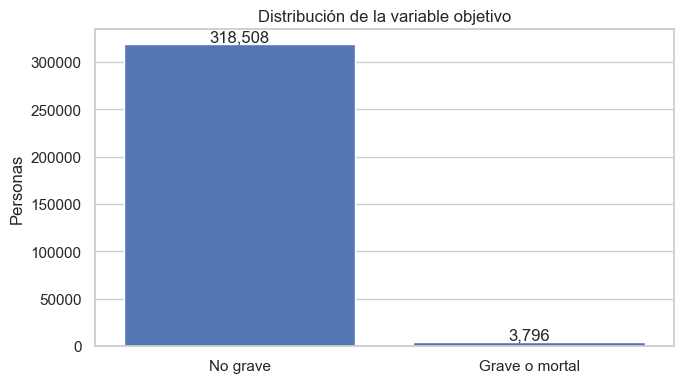

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    x=['No grave', 'Grave o mortal'],
    y=target_counts.reindex([0, 1]).values,
    color='#4472C4',
    ax=ax,
)
ax.bar_label(ax.containers[0], fmt='{:,.0f}')
ax.set(title='Distribución de la variable objetivo', xlabel='', ylabel='Personas')
plt.tight_layout()
plt.show()

**NOTA** No voy a utilizar la accuracy como métrica. Un clasificador inútil obtiene aproximadamente un 98,8 % prediciendo siempre la clase mayoritaria. Utilizaré otras mñetricas AUC, recall, precision, F1/F2, matrices de confusión, etc.

## 2. Unidad de observación y posible duplicidad

Cada fila representa una persona implicada. Varias filas comparten `num_expediente` porque pertenecen al mismo accidente. Esto no es duplicidad: es dependencia entre observaciones.

In [24]:
people_per_accident = analysis.groupby('num_expediente').size()
people_per_accident.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    137328.000000
mean          2.346965
std           1.165451
min           1.000000
50%           2.000000
75%           3.000000
90%           4.000000
95%           5.000000
99%           7.000000
max          44.000000
dtype: float64

Tiene sentido que el minimo sea 1 y la media alrededor de 2. El máximo es 44 es un outlier o es un autobús por ejemplo?? -> tenerlo en cuenta

In [25]:
duplicate_group_mask = analysis.duplicated(keep=False)
positive_duplicate_excess = analysis.loc[analysis['lesion_grave'].eq(1)].duplicated().sum()

print(f'Filas pertenecientes a grupos completamente idénticos: {duplicate_group_mask.sum():,}')
print(f'Filas que eliminaría drop_duplicates(): {analysis.duplicated().sum():,}')
print(f'Positivos redundantes bajo esa comparación: {positive_duplicate_excess:,}')
analysis.loc[duplicate_group_mask].sort_values('num_expediente').head(10)

Filas pertenecientes a grupos completamente idénticos: 23,736
Filas que eliminaría drop_duplicates(): 13,514
Positivos redundantes bajo esa comparación: 12


,num_expediente,fecha,hora,localizacion,numero,cod_distrito,distrito,tipo_accidente,estado_meteorologico,tipo_vehiculo,tipo_persona,rango_edad,sexo,cod_lesividad,lesividad,coordenada_x_utm,coordenada_y_utm,positiva_alcohol,positiva_droga,anio_fichero,fecha_hora,anio,mes,dia_semana,es_fin_semana,hora_dia,es_noche,lesividad_conocida,lesion_grave
10,2019S000002,2019-01-01,3:50:00,"CALL. CUART DE POBLET, 65",65,10,LATINA,Choque contra obstáculo fijo,Despejado,Turismo,Conductor,Desconocido,Desconocido,14,NaN,436473.0,4472030.0,N,NaN,2019,2019-01-01 03:50:00,2019,1,1,0,3,1,True,0
11,2019S000002,2019-01-01,3:50:00,"CALL. CUART DE POBLET, 65",65,10,LATINA,Choque contra obstáculo fijo,Despejado,Turismo,Conductor,Desconocido,Desconocido,14,NaN,436473.0,4472030.0,N,NaN,2019,2019-01-01 03:50:00,2019,1,1,0,3,1,True,0
19,2019S000006,2019-01-01,8:10:00,CALL. CASTRO DE ORO / CALL. FERREIRA,16,11,CARABANCHEL,Choque contra obstáculo fijo,Despejado,Turismo,Conductor,Desconocido,Desconocido,14,NaN,438116.0,4471171.0,N,NaN,2019,2019-01-01 08:10:00,2019,1,1,0,8,0,True,0
20,2019S000006,2019-01-01,8:10:00,CALL. CASTRO DE ORO / CALL. FERREIRA,16,11,CARABANCHEL,Choque contra obstáculo fijo,Despejado,Turismo,Conductor,Desconocido,Desconocido,14,NaN,438116.0,4471171.0,N,NaN,2019,2019-01-01 08:10:00,2019,1,1,0,8,0,True,0
22,2019S000007,2019-01-01,8:05:00,CALL. ARROYO FONTARRON / CALL. HACIENDA DE PAV...,1,14,MORATALAZ,Colisión fronto-lateral,Despejado,Autobús,Pasajero,De 15 a 17 años,Hombre,14,Sin asistencia sanitaria,446672.0,4472222.0,N,NaN,2019,2019-01-01 08:05:00,2019,1,1,0,8,0,True,0
23,2019S000007,2019-01-01,8:05:00,CALL. ARROYO FONTARRON / CALL. HACIENDA DE PAV...,1,14,MORATALAZ,Colisión fronto-lateral,Despejado,Autobús,Pasajero,De 15 a 17 años,Hombre,14,Sin asistencia sanitaria,446672.0,4472222.0,N,NaN,2019,2019-01-01 08:05:00,2019,1,1,0,8,0,True,0
26,2019S000007,2019-01-01,8:05:00,CALL. ARROYO FONTARRON / CALL. HACIENDA DE PAV...,1,14,MORATALAZ,Colisión fronto-lateral,Despejado,Turismo,Pasajero,De 18 a 20 años,Hombre,14,Sin asistencia sanitaria,446672.0,4472222.0,N,NaN,2019,2019-01-01 08:05:00,2019,1,1,0,8,0,True,0
27,2019S000007,2019-01-01,8:05:00,CALL. ARROYO FONTARRON / CALL. HACIENDA DE PAV...,1,14,MORATALAZ,Colisión fronto-lateral,Despejado,Turismo,Pasajero,De 18 a 20 años,Hombre,14,Sin asistencia sanitaria,446672.0,4472222.0,N,NaN,2019,2019-01-01 08:05:00,2019,1,1,0,8,0,True,0
36,2019S000014,2019-01-01,15:55:00,"CALL. PUEBLA DE SANABRIA, 2",2,17,VILLAVERDE,Choque contra obstáculo fijo,Despejado,Turismo,Conductor,Desconocido,Desconocido,14,NaN,439439.0,4466846.0,N,NaN,2019,2019-01-01 15:55:00,2019,1,1,0,15,0,True,0
37,2019S000014,2019-01-01,15:55:00,"CALL. PUEBLA DE SANABRIA, 2",2,17,VILLAVERDE,Choque contra obstáculo fijo,Despejado,Turismo,Conductor,Desconocido,Desconocido,14,NaN,439439.0,4466846.0,N,NaN,2019,2019-01-01 15:55:00,2019,1,1,0,15,0,True,0


**NOTA:** al fina no eliminaré los duplicados. Sin identificador individual no podemos distinguir entre duplicados y personas diferentes con los mismos atributos publicados. Creo que lo más limpio es considerar que no son errores.  IMPORTANTE: dos filas con el mismo expediente tienen que estar en la misma partición temporal train/test para evitar data leakege

## 3. Valores ausentes y cardinalidad

In [26]:
quality = build_quality_report(analysis)
quality[['variable', 'tipo', 'n_nulos', 'pct_nulos', 'n_unicos']].head(20)

,variable,tipo,n_nulos,pct_nulos,n_unicos
18,positiva_droga,float64,321279,99.681977,1
14,lesividad,object,145189,45.047222,8
8,estado_meteorologico,object,35713,11.080533,7
9,tipo_vehiculo,object,1767,0.548240,40
17,positiva_alcohol,object,1153,0.357737,2
15,coordenada_x_utm,float64,62,0.019236,17993
16,coordenada_y_utm,float64,62,0.019236,18439
7,tipo_accidente,object,9,0.002792,13
5,cod_distrito,string,8,0.002482,21
6,distrito,object,8,0.002482,21


In [35]:
positivos_droga = analysis.groupby(['positiva_droga'], dropna=False).size()
print(positivos_droga)

positiva_droga
1.0      1025
NaN    321279
dtype: int64


In [36]:
positivos_alc = analysis.groupby(['positiva_alcohol'], dropna=False).size()
print(positivos_alc)

positiva_alcohol
N      311917
S        9234
NaN      1153
dtype: int64


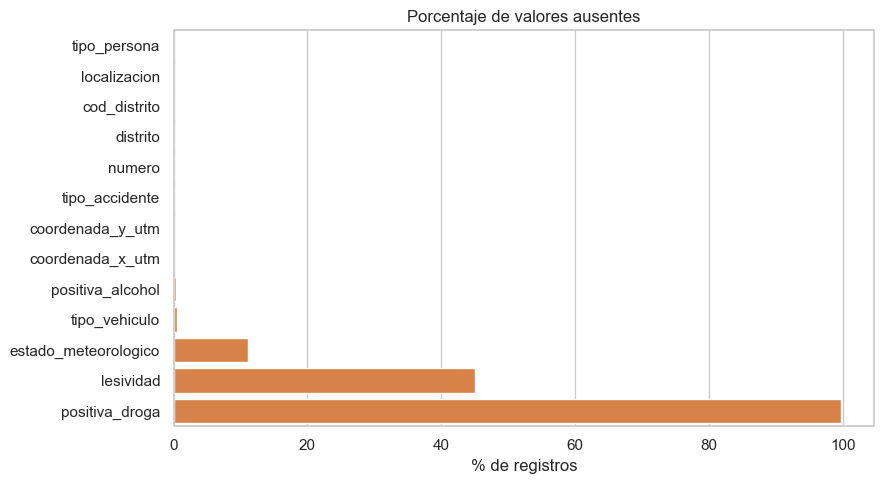

In [37]:
missing = quality.loc[quality['pct_nulos'].gt(0)].sort_values('pct_nulos')

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=missing, x='pct_nulos', y='variable', color='#ED7D31', ax=ax)
ax.set(title='Porcentaje de valores ausentes', xlabel='% de registros', ylabel='')
plt.tight_layout()
plt.show()

Los valores ausentes no peuden imputarse igual todos. Creo que es evidente que el de drogas es porque no se realizó la prueba o no dió positivo (solo hay o 1 o NaN), mientras que alcohol hay muchos N (y algunos Nan). La lesividad si es 0 nos dice la página que es que no hizo falta atención médica


## 4. Función auxiliar para tasas por grupo

Me hago una función que me da la tasa de positivos por cada grupo de una variable. Esto es útil para ver cómo afectan en un análisis exploratorio inicial. El lift es cuántas veces más aparecen los positivos en una categoría vs al ratio del global


In [45]:
def target_rate_table(dataframe: pd.DataFrame, column: str, min_count: int = 100, ) -> pd.DataFrame:

    
    """Resume volumen, positivos, tasa y lift frente a la prevalencia global.
    
    Argumentos
    
    column (str) :columna en la que miro los positivos.
    min_count (int) : minimo de registros para incluir una categoría. Por defecto 100
    """
    
    global_rate = dataframe['lesion_grave'].mean()
    
    summary = (dataframe.assign(**{column: dataframe[column].fillna('No consta')}).groupby(column, dropna=False)
            .agg(
                registros=('lesion_grave', 'size'),
                positivos=('lesion_grave', 'sum'),
                tasa_grave=('lesion_grave', 'mean'),
            )
            .query('registros >= @min_count')
            .assign(lift=lambda df: df['tasa_grave'] / global_rate)
            .sort_values(['tasa_grave', 'registros'], ascending=[False, False])
    )
    return summary

target_rate_table(analysis, 'tipo_persona')

,registros,positivos,tasa_grave,lift
tipo_persona,,,,
Peatón,10988,1214,0.110484,9.380792
Conductor,259737,2275,0.008759,0.743682
Pasajero,51574,306,0.005933,0.503767


## 5. Perfil de la persona

In [46]:
person_rate = target_rate_table(analysis, 'tipo_persona')
age_rate = target_rate_table(analysis, 'rango_edad')
sex_rate = target_rate_table(analysis, 'sexo')
display(person_rate)
display(age_rate)
display(sex_rate)

,registros,positivos,tasa_grave,lift
tipo_persona,,,,
Peatón,10988,1214,0.110484,9.380792
Conductor,259737,2275,0.008759,0.743682
Pasajero,51574,306,0.005933,0.503767


,registros,positivos,tasa_grave,lift
rango_edad,,,,
Más de 74 años,7290,337,0.046228,3.925020
De 70 a 74 años,4695,108,0.023003,1.953114
De 15 a 17 años,2618,53,0.020244,1.718881
De 65 a 69 años,7185,144,0.020042,1.701669
De 10 a 14 años,3090,50,0.016181,1.373887
De 6 a 9 años,2064,29,0.014050,1.192965
De 60 a 64 años,14763,203,0.013751,1.167511
De 25 a 29 años,32754,422,0.012884,1.093925
De 30 a 34 años,32637,408,0.012501,1.061425


,registros,positivos,tasa_grave,lift
sexo,,,,
Hombre,194747,2711,0.013921,1.181948
Mujer,93339,1082,0.011592,0.984246
Desconocido,34218,3,0.000088,0.007444


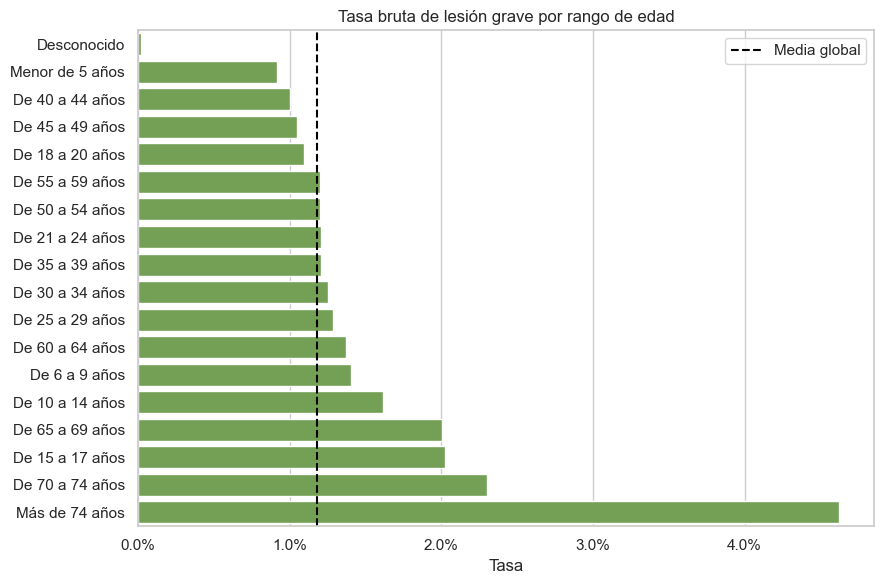

In [47]:
plot_data = age_rate.reset_index().sort_values('tasa_grave')
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=plot_data, x='tasa_grave', y='rango_edad', color='#70AD47', ax=ax)
ax.axvline(target_prevalence, color='black', linestyle='--', label='Media global')
ax.xaxis.set_major_formatter(lambda value, _: f'{value:.1%}')
ax.set(title='Tasa bruta de lesión grave por rango de edad', xlabel='Tasa', ylabel='')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Circunstancias del accidente

In [48]:
accident_rate = target_rate_table(analysis, 'tipo_accidente')
vehicle_rate = target_rate_table(analysis, 'tipo_vehiculo', min_count=250)
weather_rate = target_rate_table(analysis, 'estado_meteorologico')
display(accident_rate)
display(vehicle_rate.head(20))
display(weather_rate)

,registros,positivos,tasa_grave,lift
tipo_accidente,,,,
Atropello a persona,20983,1224,0.058333,4.952829
Caída,18728,508,0.027125,2.303095
Solo salida de la vía,1446,39,0.026971,2.290002
Vuelco,1265,22,0.017391,1.476630
Colisión frontal,7789,113,0.014508,1.231789
Colisión fronto-lateral,81826,1023,0.012502,1.061509
Choque contra obstáculo fijo,38042,238,0.006256,0.531194
Atropello a animal,583,3,0.005146,0.436910
Colisión lateral,48281,212,0.004391,0.372820


,registros,positivos,tasa_grave,lift
tipo_vehiculo,,,,
Motocicleta > 125cc,13896,896,0.064479,5.474667
Motocicleta hasta 125cc,21130,880,0.041647,3.536085
Bicicleta EPAC (pedaleo asistido),1312,46,0.035061,2.976895
VMU eléctrico,3697,129,0.034893,2.962646
Bicicleta,5529,192,0.034726,2.948452
Otros vehículos con motor,1169,35,0.029940,2.542102
Ciclomotor,4079,119,0.029174,2.477038
Autobus EMT,264,6,0.022727,1.929687
Autobús,8709,137,0.015731,1.335647


,registros,positivos,tasa_grave,lift
estado_meteorologico,,,,
Nublado,20095,315,0.015676,1.330951
Despejado,239923,3218,0.013413,1.138816
LLuvia intensa,4319,49,0.011345,0.963280
Lluvia débil,19042,189,0.009925,0.842731
Se desconoce,2922,22,0.007529,0.639267
Nevando,221,1,0.004525,0.384191
No consta,35713,2,0.000056,0.004755


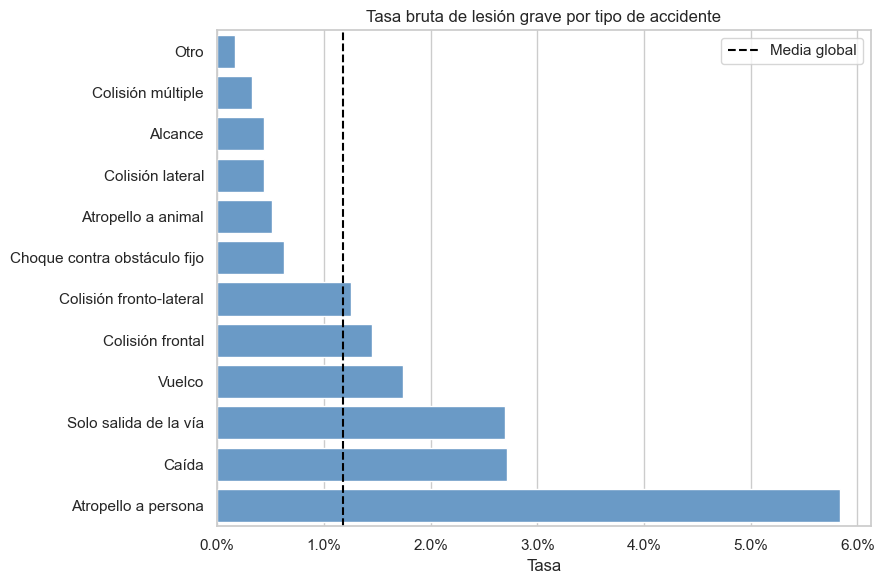

In [49]:
plot_data = accident_rate.reset_index().sort_values('tasa_grave')
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=plot_data, x='tasa_grave', y='tipo_accidente', color='#5B9BD5', ax=ax)
ax.axvline(target_prevalence, color='black', linestyle='--', label='Media global')
ax.xaxis.set_major_formatter(lambda value, _: f'{value:.1%}')
ax.set(title='Tasa bruta de lesión grave por tipo de accidente', xlabel='Tasa', ylabel='')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Patrones temporales y estabilidad

In [51]:
anual = (
    analysis.groupby('anio')
        .agg(
            registros=('lesion_grave', 'size'),
            positivos=('lesion_grave', 'sum'),
            tasa_grave=('lesion_grave', 'mean'),
            expedientes=('num_expediente', 'nunique'),
        )
        .reset_index()
)
anual

,anio,registros,positivos,tasa_grave,expedientes
0,2019,51809,573,0.011060,21934
1,2020,32430,442,0.013629,14172
2,2021,41783,584,0.013977,17952
3,2022,47051,518,0.011009,20212
4,2023,48826,589,0.012063,20672
5,2024,49338,597,0.012100,20698
6,2025,51067,493,0.009654,21688


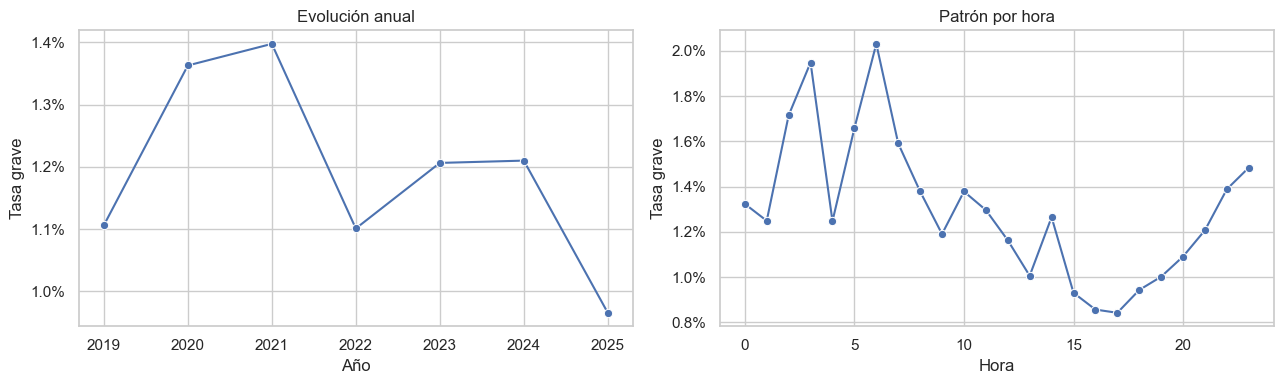

In [52]:
horario = target_rate_table(analysis, 'hora_dia', min_count=1).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=anual, x='anio', y='tasa_grave', marker='o', ax=axes[0])
sns.lineplot(data=horario, x='hora_dia', y='tasa_grave', marker='o', ax=axes[1])
axes[0].set(title='Evolución anual', xlabel='Año', ylabel='Tasa grave')
axes[1].set(title='Patrón por hora', xlabel='Hora', ylabel='Tasa grave')
for ax in axes:
    ax.yaxis.set_major_formatter(lambda value, _: f'{value:.1%}')
plt.tight_layout()
plt.show()

Las variables periódicas no se tratarán como magnitudes lineales en la regresión logística: 23:00 y 00:00 están próximas, aunque sus números sean 23 y 0. Una forma ingeniosa de tratar este problema es usar el seno y el coseno (sería como considerar el ángulo del reloj o algo así)

## 8. Distribución espacial por distrito

In [53]:
district_rate = target_rate_table(analysis, 'distrito')
district_rate

,registros,positivos,tasa_grave,lift
distrito,,,,
CHAMBERÍ,14901,222,0.014898,1.264961
ARGANZUELA,15135,210,0.013875,1.178084
CHAMARTÍN,22515,312,0.013857,1.176582
SALAMANCA,23090,319,0.013816,1.173022
CENTRO,17309,219,0.012652,1.074265
VILLA DE VALLECAS,8635,109,0.012623,1.071775
LATINA,15584,195,0.012513,1.062417
MONCLOA-ARAVACA,16827,206,0.012242,1.039441
SAN BLAS-CANILLEJAS,16223,197,0.012143,1.031038


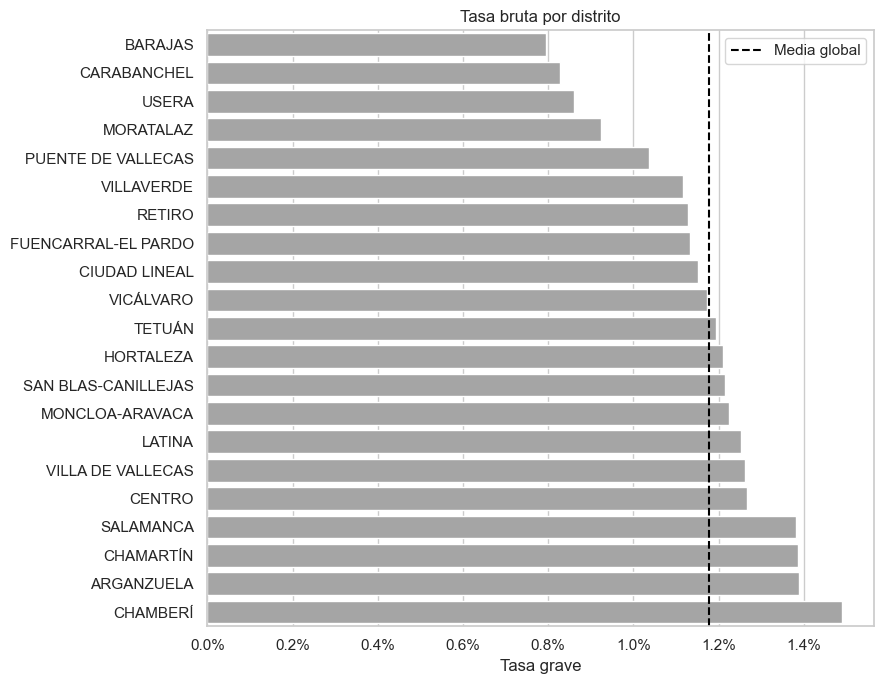

In [54]:
plot_data = district_rate.reset_index().sort_values('tasa_grave')
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=plot_data, x='tasa_grave', y='distrito', color='#A5A5A5', ax=ax)
ax.axvline(target_prevalence, color='black', linestyle='--', label='Media global')
ax.xaxis.set_major_formatter(lambda value, _: f'{value:.1%}')
ax.set(title='Tasa bruta por distrito', xlabel='Tasa grave', ylabel='')
ax.legend()
plt.tight_layout()
plt.show()

En el primer modelo usaremos distrito, que es interpretable y fácil de introducir en la aplicación.

## 9. Alcohol y drogas: análisis, pero no predicción principal

In [55]:
for column in ['positiva_alcohol', 'positiva_droga']:
    print(f'\n{column}: {analysis[column].isna().mean():.1%} de valores ausentes')
    display(target_rate_table(analysis, column, min_count=1))


positiva_alcohol: 0.4% de valores ausentes


,registros,positivos,tasa_grave,lift
positiva_alcohol,,,,
S,9234,122,0.013212,1.121785
N,311917,3674,0.011779,1.000091
No consta,1153,0,0.000000,0.000000



positiva_droga: 99.7% de valores ausentes


,registros,positivos,tasa_grave,lift
positiva_droga,,,,
1.0,1025,53,0.051707,4.390273
No consta,321279,3743,0.011650,0.989184


Curiosamente hay relativamente poco lift con el alcohol (12% es bastante pero esperaría más). Con las drogas hay muchísimo. El problema es que los resultados de alcolhemia/teste de drogas se conocen _después_ del accidente, por lo que no los incluyo.

## 10. Decisión variable por variable

In [63]:
#Tomo nota de las decisiones (queda mejor para ponerlo luego en la memoria)

variable_decisions = pd.DataFrame([
    ('num_expediente', 'Agrupar', 'Identificador. Evita fugas entre particiones.'),
    ('cod_lesividad / lesividad', 'Excluir', 'Definen directamente la variable objetivo.'),
    ('fecha / hora / fecha_hora', 'Transformar', 'Se transforman en ciclicas.'),
    ('anio_fichero', 'Excluir', 'Variable técnica redundante con la fecha.'),
    ('localizacion / numero', 'Excluir inicialmente', 'Texto grande y difícil entrada en la aplicación.'),
    ('cod_distrito', 'Excluir', 'Redundante con distrito.'),
    ('distrito', 'Incluir', 'Localización interpretable y disponible.'),
    ('coordenadas UTM', 'Posible Mejora futura', 'Necesitan tratamiento especial'),
    ('tipo_accidente', 'Incluir', 'Tener en cuenta que se conoce despúes de que ocurra el accidente.'),
    ('estado_meteorologico', 'Incluir', 'Disponible en el momento del accidente.'),
    ('tipo_vehiculo', 'Incluir', 'Disponible e interpretable.'),
    ('tipo_persona', 'Incluir', 'Distingue conductor, pasajero y peatón.'),
    ('rango_edad', 'Incluir con auditoría', 'RGPD y EU: Variable sensible por igualdad.'),
    ('sexo', 'Incluir con auditoría', 'RGPD y EU: Variable sensible por igualdad.'),
    ('positiva_alcohol / positiva_droga', 'Excluir del modelo principal', 'Aparecen después del accidente.'),
    ('mes / día / hora', 'Transformar', 'Codificación cíclica para modelos lineales.'),
    ('es_fin_semana / es_noche', 'Incluir', 'Indicadores interpretables.'),
], columns=['Variable', 'Decisión', 'Justificación'])
variable_decisions

,Variable,Decisión,Justificación
0,num_expediente,Agrupar,Identificador. Evita fugas entre particiones.
1,cod_lesividad / lesividad,Excluir,Definen directamente la variable objetivo.
2,fecha / hora / fecha_hora,Transformar,Se transforman en ciclicas.
3,anio_fichero,Excluir,Variable técnica redundante con la fecha.
4,localizacion / numero,Excluir inicialmente,Texto grande y difícil entrada en la aplicación.
5,cod_distrito,Excluir,Redundante con distrito.
6,distrito,Incluir,Localización interpretable y disponible.
7,coordenadas UTM,Posible Mejora futura,Necesitan tratamiento especial
8,tipo_accidente,Incluir,Tener en cuenta que se conoce despúes de que o...
9,estado_meteorologico,Incluir,Disponible en el momento del accidente.


In [64]:
categorical_features = [
    'distrito',
    'tipo_accidente',
    'estado_meteorologico',
    'tipo_vehiculo',
    'tipo_persona',
    'rango_edad',
    'sexo',
]

temporal_features = [
    'mes',
    'dia_semana',
    'hora_dia',
    'es_fin_semana',
    'es_noche',
]

model_features = categorical_features + temporal_features
target = 'lesion_grave'
group = 'num_expediente'

print('Variables iniciales:', model_features)

Variables iniciales: ['distrito', 'tipo_accidente', 'estado_meteorologico', 'tipo_vehiculo', 'tipo_persona', 'rango_edad', 'sexo', 'mes', 'dia_semana', 'hora_dia', 'es_fin_semana', 'es_noche']


## 11. Partición temporal propuesta

- **Entrenamiento:** 2019-2023.
- **Validación:** 2024. Selección de hiperparámetros, calibración y umbral.
- **Test final:** 2025. Se utiliza una sola vez al finalizar.

Esta división evalúa el uso realista del modelo sobre accidentes futuros y evita que personas del mismo expediente aparezcan en conjuntos diferentes.

In [65]:
def temporal_partition(year: int) -> str:
    if year <= 2023:
        return 'train_2019_2023'
    if year == 2024:
        return 'validation_2024'
    if year == 2025:
        return 'test_2025'
    return 'outside_scope'

split_summary = (
    analysis.assign(partition=analysis['anio'].astype(int).map(temporal_partition))
        .groupby('partition')
        .agg(
            registros=('lesion_grave', 'size'),
            positivos=('lesion_grave', 'sum'),
            prevalencia=('lesion_grave', 'mean'),
            expedientes=('num_expediente', 'nunique'),
        )
        .reindex(['train_2019_2023', 'validation_2024', 'test_2025'])
)
split_summary

,registros,positivos,prevalencia,expedientes
partition,,,,
train_2019_2023,221899,2706,0.012195,94942
validation_2024,49338,597,0.012100,20698
test_2025,51067,493,0.009654,21688


## 12. Conclusiones del EDA

1. El desbalance es severo, pero existen suficientes positivos para entrenar y evaluar.
2. La accuracy es inadecuada como métrica principal.
3. Las observaciones están agrupadas por accidente y no deben separarse aleatoriamente.
4. No hay evidencia suficiente para eliminar las filas aparentemente duplicadas.
5. La persona, el tipo de accidente y el vehículo presentan asociaciones descriptivas relevantes.
6. Alcohol y drogas se excluyen del modelo principal por disponibilidad y proceso de medición.
7. El primer modelo utilizará variables simples, interpretables y disponibles.
8. El siguiente notebook construirá una regresión logística base, todavía sin técnicas de remuestreo, para conocer la dificultad real del problema.